In [1]:
import logging
import os
import sys
import traceback
from tqdm import tqdm 

from hydra import initialize, compose
import numpy as np
import pandas as pd
from omegaconf import DictConfig
import scanpy as sc
import torch

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import sys 
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model

from torch.utils.data import TensorDataset, DataLoader

In [2]:
with initialize(config_path="../../../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm_old_measurements"
                    ])

In [3]:
config.paths["ct_classifier_path"] = "../../../../../project_folder/output/checkpoints/cell_type_classifier/2026-04-28_16-38-47/icy-terrain-18_TargetPredictionModel.pkl"

In [4]:
logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

# Classify both training and validation anndata 

In [5]:
train_data = target_prediction_model.train_data.state_data
valid_data = target_prediction_model.validation_data.state_data

In [6]:
label_train = target_prediction_model.train_data.adata.obs.cell_type.to_numpy()
label_valid = target_prediction_model.validation_data.adata.obs.cell_type.to_numpy()

In [7]:
X_concat = torch.from_numpy(np.concatenate([train_data, valid_data], axis=0))
label_concat = np.concatenate([label_train, label_valid])

## Tensor dataset for data 

In [8]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(X_concat), 
    batch_size=4026,
    shuffle=False
)

In [9]:
ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())

100%|██████████| 112/112 [00:04<00:00, 22.67it/s]


In [10]:
ct_predictions = np.concatenate(ct_predictions)

In [11]:
from sklearn.preprocessing import LabelEncoder

# Prepare label encoder
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [12]:
ct_predictions_str = classes[ct_predictions]

In [13]:
pd.DataFrame(ct_predictions_str).value_counts()

0          
MPP            78449
GMP-Neutro     74898
MgKEryPro1     63715
LMPP-CLP       40087
Early_GMP      31849
EosBasMast2    31323
GMP_cycling    25294
MPP_MgkEry     24329
MgKEryPro2     19202
EosBasMast1    16953
EryPro         16024
CyclingPro1    10110
HSCs            2590
earlyMPP        2185
MLP             1796
pre_cDC2        1792
EosBasMast3     1711
preProB         1663
late_MgkPro     1575
CD16Mono        1239
CyclingPro2      952
pre_cDC1         736
CD14Mono         584
ProB             162
Name: count, dtype: int64

In [14]:
ct_predictions_str

array(['MPP', 'LMPP-CLP', 'MPP', ..., 'MPP', 'MPP', 'MgKEryPro2'],
      shape=(449218,), dtype='<U11')

In [15]:
label_concat

array(['MPP', 'LMPP-CLP', 'MPP', ..., 'MPP', 'MPP', 'MgKEryPro2'],
      shape=(449218,), dtype=object)

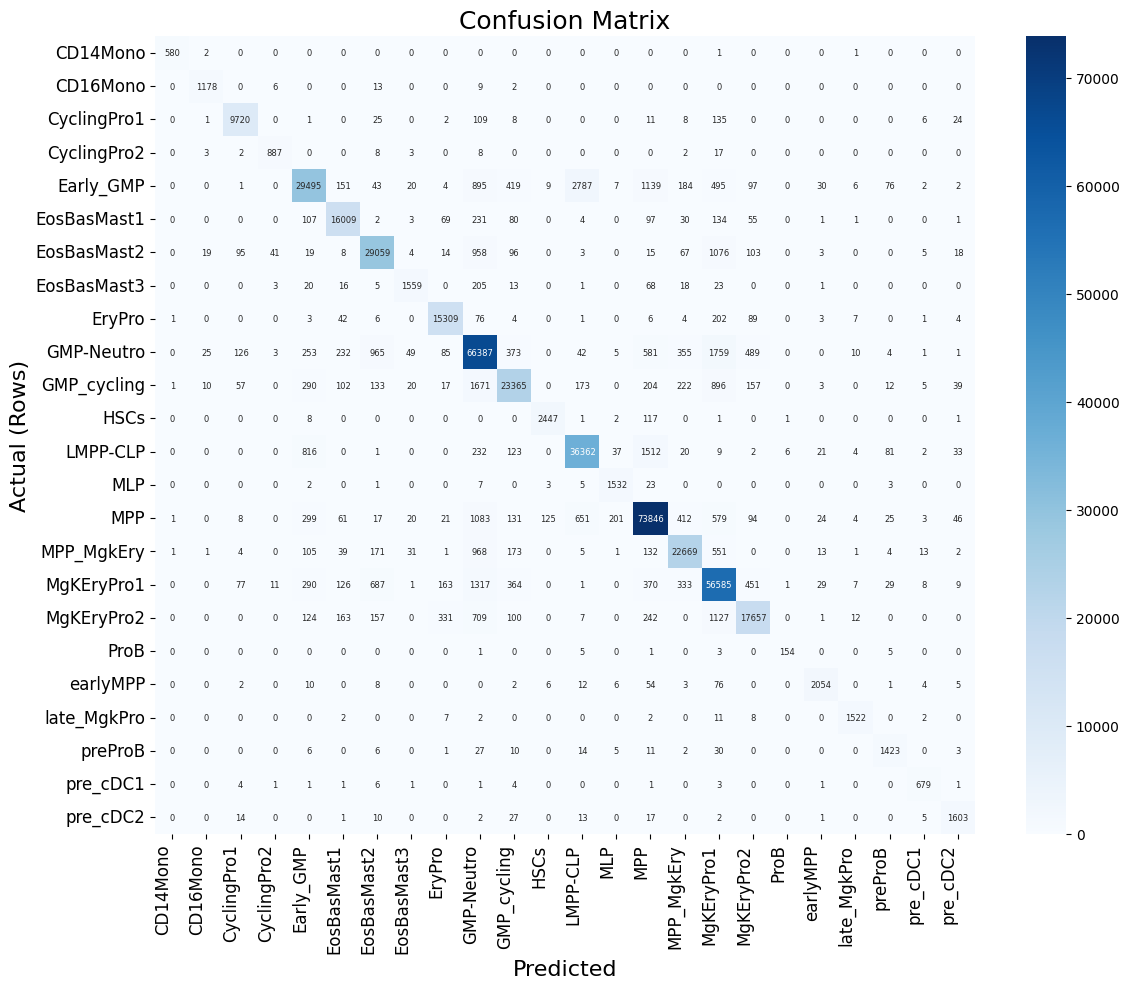

In [16]:
cm = confusion_matrix(label_concat, ct_predictions_str)

# Get labels (adjust if you have a predefined order)
labels = sorted(set(label_concat))

plt.figure(figsize=(12, 10))  # bigger figure

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 6}  # bigger numbers
)

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("Actual (Rows)", fontsize=16)
plt.title("Confusion Matrix", fontsize=18)

plt.xticks(rotation=90, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import classification_report

In [18]:
pd.DataFrame(classification_report(label_concat, ct_predictions_str, output_dict=True)).T

,precision,recall,f1-score,support
CD14Mono,0.993151,0.993151,0.993151,584.00000
CD16Mono,0.950767,0.975166,0.962812,1208.00000
CyclingPro1,0.961424,0.967164,0.964286,10050.00000
CyclingPro2,0.931723,0.953763,0.942614,930.00000
Early_GMP,0.926089,0.822458,0.871203,35862.00000
EosBasMast1,0.944317,0.951557,0.947923,16824.00000
EosBasMast2,0.927721,0.919501,0.923593,31603.00000
EosBasMast3,0.911163,0.806936,0.855888,1932.00000
EryPro,0.955379,0.971507,0.963375,15758.00000
GMP-Neutro,0.886365,0.925319,0.905423,71745.00000


In [19]:
adata_concat = sc.AnnData(X=X_concat.cpu().numpy(),
                          obs=pd.DataFrame({"cell_type": ct_predictions_str}))

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
sc.pp.subsample(adata_concat, n_obs=100_000,  random_state=42)

In [21]:
# sc.tl.pca(adata_concat)
# sc.pp.neighbors(adata_concat)
# sc.tl.umap(adata_concat)

In [22]:
# sc.pl.umap(adata_concat, color="cell_type", legend_loc="on data", s=20)

In [ ]:
# adata_concat = adata_concat[:, :20]

In [ ]:
# sc.tl.pca(adata_concat)
# sc.pp.neighbors(adata_concat)
# sc.tl.umap(adata_concat)

In [ ]:
# sc.pl.umap(adata_concat, color="cell_type", legend_loc="on data", s=20)